In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xsimlab as xs
%load_ext xsimlab.ipython


In [3]:
from fastscape.models import basic_model
from fastscape.processes import FlowAccumulator

model = basic_model.update_processes({'drainage': FlowAccumulator})

In [4]:
model.drainage

<FlowAccumulator 'drainage' (xsimlab process)>
Variables:
    runoff           [in] () or ('y', 'x') surface runoff (source t...
    shape            [in] <--- grid.shape
    cell_area        [in] <--- grid.cell_area
    stack            [in] <--- flow.stack
    nb_receivers     [in] <--- flow.nb_receivers
    receivers        [in] <--- flow.receivers
    weights          [in] <--- flow.weights
    flowacc         [out] ('y', 'x') flow accumulation from up to d...
Simulation stages:
    run_step

In [60]:
xl,yl = 200e3, 100e3
nx,ny = 201, 101
x,y =np.meshgrid(np.linspace(0,xl,nx), np.linspace(0,yl,ny))
x = xr.DataArray(x, dims=('y','x'), coords=({'x':np.linspace(0,xl,nx), 'y':np.linspace(0,yl,ny)}))
y = xr.DataArray(y, dims=('y','x'), coords=({'x':np.linspace(0,xl,nx), 'y':np.linspace(0,yl,ny)}))

tf = 10e6
nstep = 401
nout = 401
tstep = xr.DataArray(np.linspace(0,tf,nstep), dims='tstep')
time = xr.DataArray(np.linspace(0,tf,nout), dims='time')

period = xr.DataArray([0.2e6,1e6,5e6], dims='period')
precip = 1 + 0.5*np.sin(2*np.pi*tstep/period)

In [61]:
# %create_setup model
import xsimlab as xs

ds_in = xs.create_setup(
    model=model,
    clocks={'time':time, 'tstep':tstep},
    master_clock = 'tstep',
    input_vars={
        'grid__shape': [ny,nx],
        'grid__length': [yl,xl],
        'boundary__status': 'fixed_value',
        'uplift__rate': 1e-4,
        'init_topography__seed': None,
        'diffusion__diffusivity': 0.1,
        'drainage__runoff': precip,
        'spl__k_coef': 1e-5,
        'spl__area_exp': 0.45,
        'spl__slope_exp': 1,
    },
    output_vars={'topography__elevation':'time',
                 'erosion__rate':'time'}
)


In [62]:
with model, xs.monitoring.ProgressBar():
    ds_out = ds_in.xsimlab.run(batch_dim='period', check_dims='transpose').assign_coords({'period':period})

             0% | initialize 

             0% | initialize 

             0% | initialize 

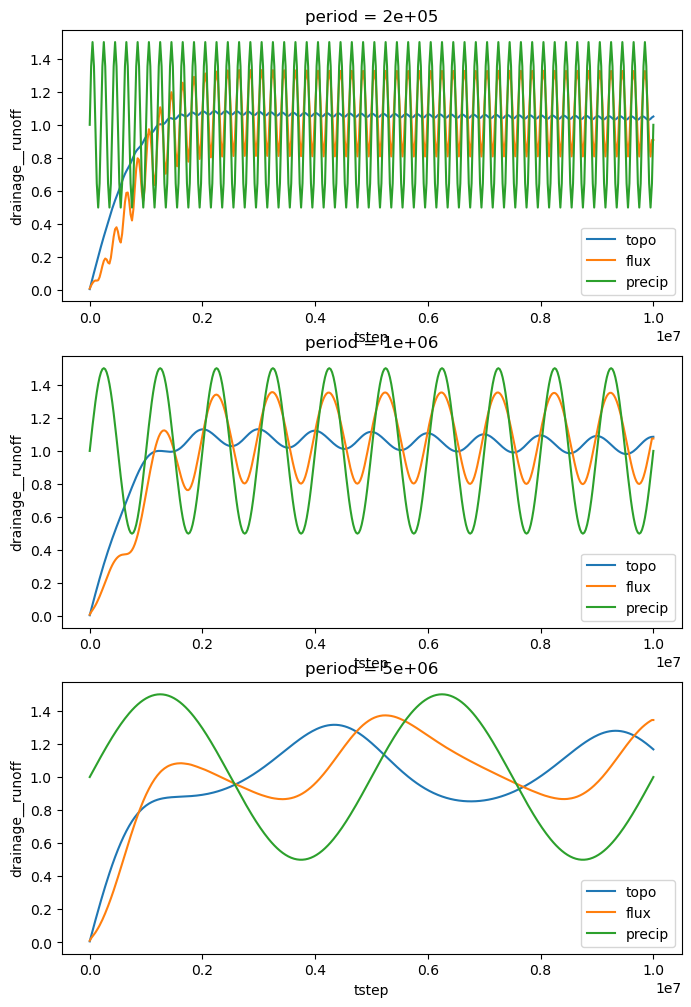

In [63]:
fig,ax = plt.subplots(nrows=3, figsize=(8,12))
for i,p in enumerate(ds_out.period):
    (ds_out.topography__elevation.mean(('x','y'))/ds_out.topography__elevation.mean(('x','y')).mean('time')).sel(period=p).plot(ax=ax[i], label='topo')
    (ds_out.erosion__rate.integrate(('x','y'))/ds_out.erosion__rate.integrate(('x','y')).mean('time')).sel(period=p).plot(ax=ax[i], label='flux')
    (ds_out.drainage__runoff/ds_out.drainage__runoff.mean('tstep')).sel(period=p).plot(ax=ax[i], label='precip')
    ax[i].legend()
fig.savefig('Figure1.pdf', bbox_inches='tight');